In [1]:
import pandas as pd
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# path_csv = r'C:\Users\Usuario\Downloads\Mice - Positioning 6.csv'
path_excel = r'C:\Users\Usuario\Downloads\Mice - Positioning 6.xlsx'

# df = pd.read_csv(path_csv)
df = pd.read_excel(path_excel)

In [3]:
# XYZ axis range limits (mm)
# From: https://optics-focus.com/manual-xyz-stage-p-782.html?zenid=cqpkn9gbslubohjbcv39u5gr70
x_lim = 6.5
y_lim = 6.5
z_lim = 10

In [4]:
# Get the mean X, Y, Z stats for each mouse
mice_stats = df.groupby('Mouse')[['X', 'Y', 'Z']].agg(['mean', 'std'])

# Compute the Z-score for each mouse's X, Y, Z values
df['X_z'] = df.groupby('Mouse')['X'].transform(lambda x: zscore(x, nan_policy='omit'))
df['Y_z'] = df.groupby('Mouse')['Y'].transform(lambda x: zscore(x, nan_policy='omit'))
df['Z_z'] = df.groupby('Mouse')['Z'].transform(lambda x: zscore(x, nan_policy='omit'))

# Identify outliers based on Z-scores
threshold = 2  # Z-score threshold for outliers (std from mean)
df['X_outlier'] = df['X_z'].abs() > threshold
df['Y_outlier'] = df['Y_z'].abs() > threshold
df['Z_outlier'] = df['Z_z'].abs() > threshold
df['Outlier'] = df[['X_outlier', 'Y_outlier', 'Z_outlier']].any(axis=1)

# Find indexes when Outlier is True
outlier_indexes = df.index[df['Outlier']].tolist()
print(f'Total outliers detected with a threshold of {threshold} std: {len(outlier_indexes)}')

# Print the mouse, date and axis of the outlier for manual inspection
for index in outlier_indexes:
    mouse = df.at[index, 'Mouse']
    date = df.at[index, 'Date']
    x_outlier = df.at[index, 'X_outlier']
    y_outlier = df.at[index, 'Y_outlier']
    z_outlier = df.at[index, 'Z_outlier']

    if x_outlier:
        print(f"Outlier detected: Mouse {mouse}, Date {date}, Axis X")
    if y_outlier:
        print(f"Outlier detected: Mouse {mouse}, Date {date}, Axis Y")
    if z_outlier:
        print(f"Outlier detected: Mouse {mouse}, Date {date}, Axis Z")

# Overwrite the XYZ values with NaN if outliers for each axis
df.loc[df['X_outlier'], 'X'] = pd.NA
df.loc[df['Y_outlier'], 'Y'] = pd.NA
df.loc[df['Z_outlier'], 'Z'] = pd.NA

# Recompute mouse stats after removing outliers
mice_stats = df.groupby('Mouse')[['X', 'Y', 'Z']].agg(['mean', 'std'])
mice_stats = mice_stats.round(2)

Total outliers detected with a threshold of 2 std: 15
Outlier detected: Mouse 19, Date 2025-06-12 00:00:00, Axis X
Outlier detected: Mouse 22, Date 2025-06-12 00:00:00, Axis Z
Outlier detected: Mouse 24, Date 2025-06-12 00:00:00, Axis X
Outlier detected: Mouse 17, Date 2025-06-13 00:00:00, Axis Y
Outlier detected: Mouse 17, Date 2025-06-13 00:00:00, Axis Z
Outlier detected: Mouse 21, Date 2025-06-16 00:00:00, Axis Y
Outlier detected: Mouse 25, Date 2025-06-16 00:00:00, Axis Y
Outlier detected: Mouse 23, Date 2025-06-17 00:00:00, Axis Y
Outlier detected: Mouse 22, Date 2025-06-18 00:00:00, Axis Y
Outlier detected: Mouse 14, Date 2025-06-19 00:00:00, Axis X
Outlier detected: Mouse 15, Date 2025-06-19 00:00:00, Axis X
Outlier detected: Mouse 21, Date 2025-06-23 00:00:00, Axis Z
Outlier detected: Mouse 23, Date 2025-06-23 00:00:00, Axis X
Outlier detected: Mouse 14, Date 2025-06-25 00:00:00, Axis Y
Outlier detected: Mouse 20, Date 2025-06-25 00:00:00, Axis X
Outlier detected: Mouse 20, Dat

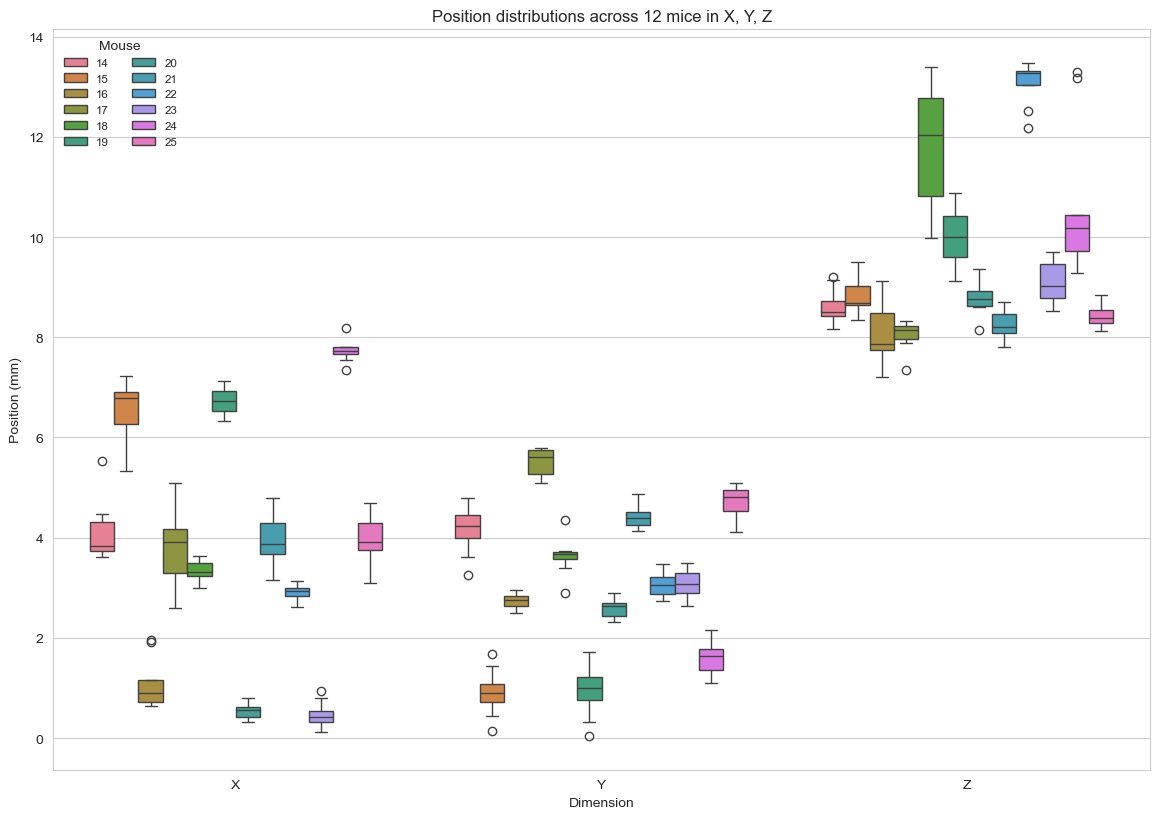

In [5]:
# Plot the stats per mouse
# Make a melted DataFrame for easier plotting
df['Mouse'] = df['Mouse'].astype(str)  # Ensure Mouse is a string for better plotting
df_melt = df.melt(id_vars=['Mouse'], value_vars=['X', 'Y', 'Z'], var_name='Dimension', value_name='Position')

plt.figure(figsize=(11.7, 8.3))
sns.boxplot(x='Dimension', y='Position', hue='Mouse', data=df_melt)
plt.title('Position distributions across 12 mice in X, Y, Z')
plt.ylabel('Position (mm)')
plt.legend(title='Mouse', loc='upper left', ncol=2, fontsize='small', frameon=False)
plt.tight_layout()
plt.show()